# Quantitative Regel-Adhärenz & Metriken-Evaluation für Leichte Sprache

## 1. Systematische Übersicht: Alle 14 Regeln, Metriken & Technologien

| # | Regelbereich | Offizielle LS-Regel | Quantitative Metrik | Technologie & Parser | Zielrichtung (LS vs. AS) |

| :--- | :--- | :--- | :--- | :--- | :--- |

| **S1** | **Syntax** | **Kurze Sätze** (max. 8–12 Wörter) | Mean Sentence Length (MSL) & Long Sentence Ratio (>12 Wörter) | `spacy` (`de_core_news_lg`): `doc.sents` | $\downarrow$ MSL $\le 8-10$, Long Sents $\approx 0$ |

| **S2** | **Syntax** | **Keine Nebensätze** (Nur Hauptsätze, Parataxe) | Subordination Ratio (Nebensätze pro Satz) | `spacy` Dep (`relcl`, `advcl`, `ccomp`) & POS (`SCONJ`) | $\downarrow$ Sinkt drastisch gegen $0.0$ |

| **S3** | **Syntax** | **SPO-Struktur** (Subjekt-Prädikat-Objekt) | Subject-Initial Sentence Ratio | `spacy` Dependency Parsing: `sb` am Satzanfang | $\uparrow$ Steigt in LS |

| **G1** | **Grammatik** | **Kein Passiv** (Nur Aktivformulierungen) | Passive Voice Ratio (Passivkonstruktionen pro Satz) | `spacy` Morph/Dep: `sb_pass` & *werden* + Partizip II | $\downarrow$ Sinkt gegen $0.0$ |

| **G2** | **Grammatik** | **Kein Genitiv** (Ersatz durch Dativ mit *von*) | Genitive Noun Ratio (Genitive pro Nomen/Pronomen) | `spacy` Morph: `Case=Gen` | $\downarrow$ Sinkt um $>85\%$ bis $100\%$ |

| **G3** | **Grammatik** | **Kein Konjunktiv** (Nur Indikativ/Tatsachen) | Subjunctive Mood Ratio (Konjunktiv pro finitem Verb) | `spacy` Morph: `Mood=Sub` | $\downarrow$ Nahezu $0.0$ |

| **G4** | **Grammatik** | **Verbalstil statt Nominalstil** | Nominalization Density & Verb-to-Noun Ratio | `regex` Suffixfilter (`-ung`, `-heit`, etc.) + POS | $\downarrow$ Nominalisierungen sinken; VNR $\uparrow$ |

| **G5** | **Grammatik** | **Wenig/keine Verneinungen** | Negation Density (*nicht*, *kein*, *weder*, etc.) | `regex` / Lemma-Matching | $\downarrow$ Sinkt in LS |

| **L1** | **Lexik** | **Kurze, einfache Wörter** | Polysyllable Ratio ($\ge 3$ Silben) & Mittlere Wortlänge | `pyphen` (de_DE Silbentrennung) & `textstat` | $\downarrow$ Sinkt signifikant |

| **L2** | **Lexik** | **Komposita trennen** (Bindestrich / Mediopunkt) | Compound Hyphenation Ratio | `regex`: Substantive mit `-` oder `·` | $\uparrow$ Steigt in LS stark an |

| **L3** | **Lexik** | **Keine Abkürzungen** (Wörter ausschreiben) | Abbreviation Density (*z. B.*, *bzw.*, Akronyme) | `regex` Pattern Matching | $\downarrow$ Sinkt gegen $0.0$ |

| **L4** | **Lexik** | **Zahlen als Ziffern** (*12* statt *zwölf*) | Digit Ratio (Ziffern vs. Zahlwörter) | `regex`: `\d+` vs. Zahlwort-Wörterbuch | $\uparrow$ Steigt gegen $1.0$ |

| **K1** | **Lesbarkeit**| **Standard-Lesbarkeitsformeln** | Wiener Sachtextformel (WSTF) & Flesch (DE) | `textstat` (lang='de') | WSTF sinkt (Ziel $\le 6$); Flesch $>70$ |

| **S1** | **Semantik** | **Sinn- & Fakten-Erhaltung** | Dense SBERT Semantic Similarity | `sentence-transformers` (Jina v2 8192) | Hohe Ähnlichkeit ($0.70 - 0.95$) |


In [1]:
import os, sys

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Arbeitsverzeichnis setzen
while not (os.path.exists("data") and os.path.exists("scripts")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")
print("Arbeitsverzeichnis:", os.getcwd())

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


## 2. Korpus-Analyse: Wie streng halten sich die 12 Quellen an die Regeln?


In [2]:
corpus_file = os.path.join(REPO_ROOT, "data/analysis/rule_adherence_corpus.csv")
if not os.path.exists(corpus_file):
    corpus_file = os.path.join(REPO_ROOT, "data/analysis/rule_adherence_corpus.csv")
if not os.path.exists(corpus_file):
    corpus_file = "data/analysis/rule_adherence_corpus.csv"

df_corpus = pd.read_csv(corpus_file)
print(f"Geladene Artikelpaare: {len(df_corpus)} aus {df_corpus['source'].nunique()} Quellen.")

cols_overview = [
    'as_avg_sent_len', 'ls_avg_sent_len', 'red_red_sent_len_pct',
    'as_passive_ratio', 'ls_passive_ratio', 'red_red_passive_pct',
    'as_genitive_ratio', 'ls_genitive_ratio', 'red_red_genitive_pct',
    'as_wstf_score', 'ls_wstf_score'
]

grouped_corpus = df_corpus.groupby('source')[cols_overview].mean().round(2)
grouped_corpus.columns = [
    'AS Satzlänge', 'LS Satzlänge', 'Satzkürzung (%)',
    'AS Passiv/Satz', 'LS Passiv/Satz', 'Passiv-Red. (%)',
    'AS Genitiv-Quote', 'LS Genitiv-Quote', 'Genitiv-Red. (%)',
    'AS WSTF', 'LS WSTF'
]
display(grouped_corpus)


Geladene Artikelpaare: 860 aus 12 Quellen.


,AS Satzlänge,LS Satzlänge,Satzkürzung (%),AS Passiv/Satz,LS Passiv/Satz,Passiv-Red. (%),AS Genitiv-Quote,LS Genitiv-Quote,Genitiv-Red. (%),AS WSTF,LS WSTF
source,,,,,,,,,,,
apotheken,12.26,6.94,42.41,0.05,0.01,49.88,0.05,0.03,37.59,11.04,7.70
behindertenbeauftragter,15.58,8.39,44.22,0.05,0.04,7.94,0.10,0.03,74.92,11.83,8.58
brandeins,17.22,6.96,55.77,0.11,0.02,27.63,0.10,0.00,98.05,11.15,3.43
hamburg,13.51,6.56,48.78,0.07,0.02,60.05,0.08,0.01,89.51,11.70,6.10
hannover,11.63,6.59,39.28,0.05,0.00,58.01,0.06,0.00,85.52,11.09,6.76
koeln,12.02,7.86,33.39,0.08,0.01,75.92,0.09,0.01,92.43,11.51,5.91
main_taunus,11.26,7.15,30.48,0.03,0.00,29.65,0.04,0.01,49.93,10.61,6.36
mdr,10.14,8.30,17.28,0.05,0.06,-45.73,0.05,0.01,79.43,9.50,6.44
sozialpolitik,13.10,7.60,41.56,0.07,0.01,83.71,0.07,0.01,84.31,11.27,7.20


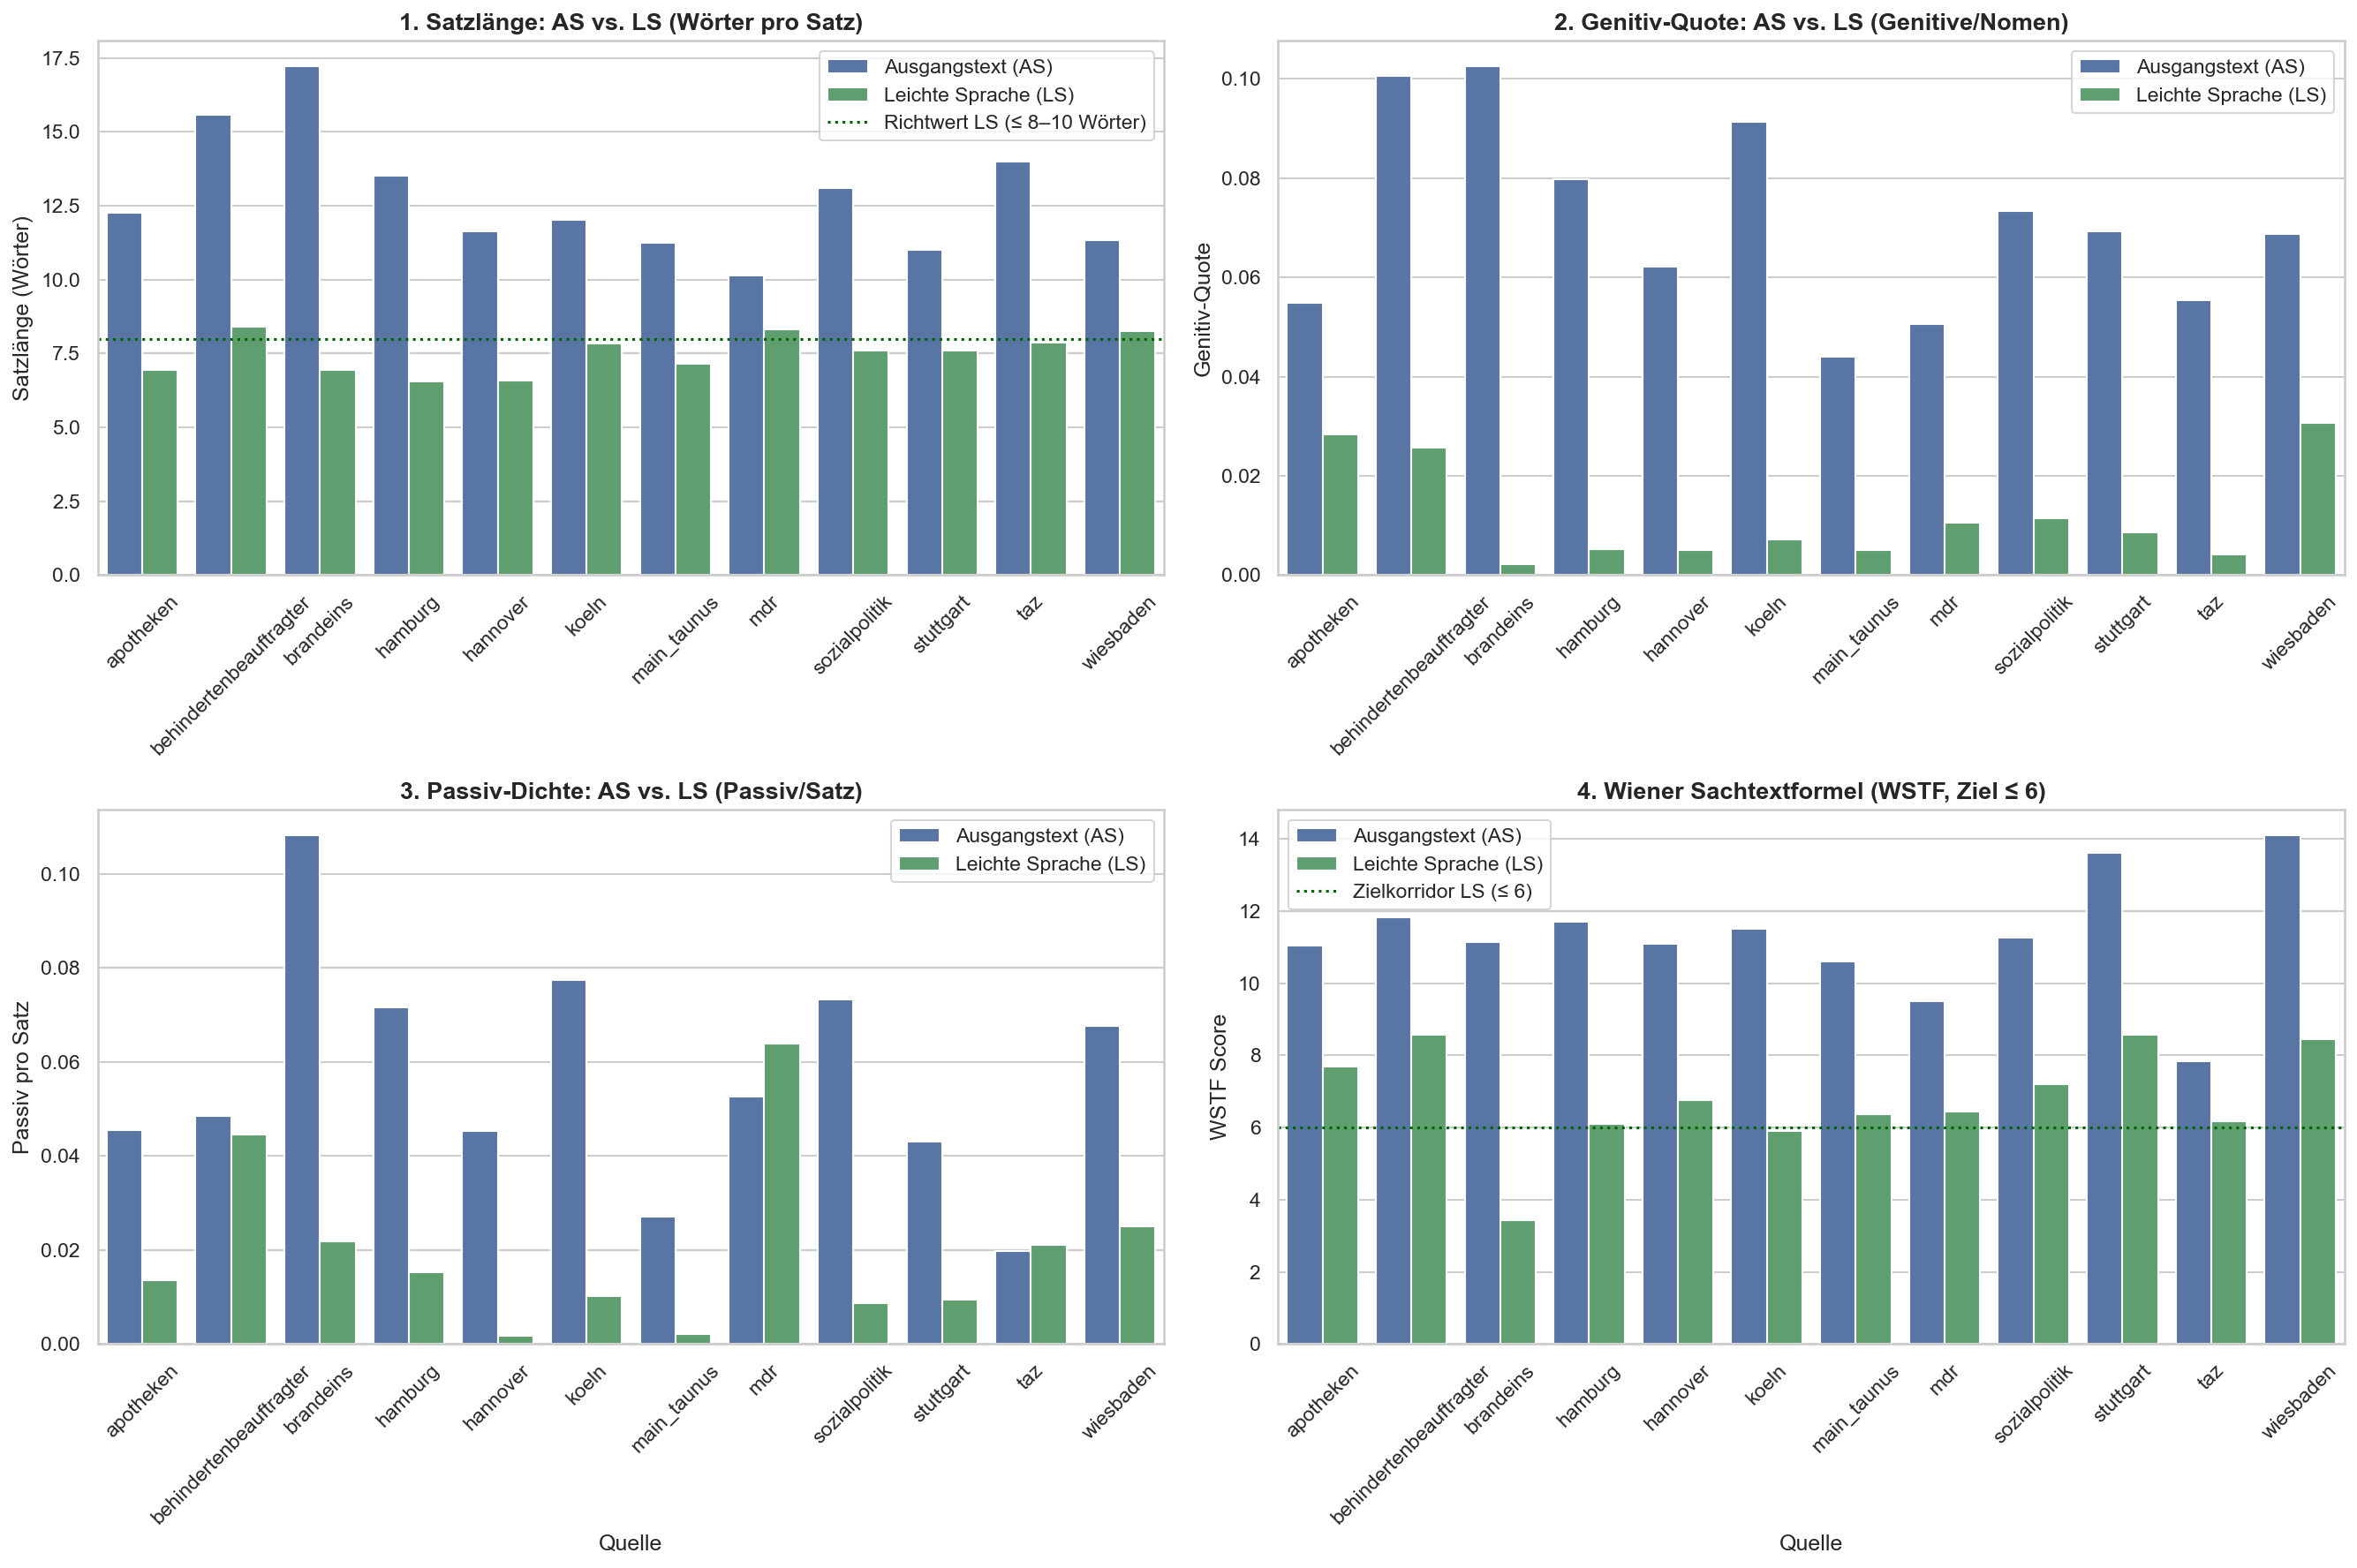

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Satzlänge
df_sent = df_corpus.groupby('source')[['as_avg_sent_len', 'ls_avg_sent_len']].mean().reset_index()
df_sent_m = df_sent.melt(id_vars='source', var_name='Texttyp', value_name='Satzlänge (Wörter)')
df_sent_m['Texttyp'] = df_sent_m['Texttyp'].map({'as_avg_sent_len': 'Ausgangstext (AS)', 'ls_avg_sent_len': 'Leichte Sprache (LS)'})
sns.barplot(data=df_sent_m, x='source', y='Satzlänge (Wörter)', hue='Texttyp', ax=axes[0, 0], palette=['#4c72b0', '#55a868'])
axes[0, 0].set_title('1. Satzlänge: AS vs. LS (Wörter pro Satz)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].axhline(8.0, color='darkgreen', linestyle=':', label='Richtwert LS (≤ 8–10 Wörter)')
axes[0, 0].legend()

# Genitiv-Quote
df_gen = df_corpus.groupby('source')[['as_genitive_ratio', 'ls_genitive_ratio']].mean().reset_index()
df_gen_m = df_gen.melt(id_vars='source', var_name='Texttyp', value_name='Genitiv-Quote')
df_gen_m['Texttyp'] = df_gen_m['Texttyp'].map({'as_genitive_ratio': 'Ausgangstext (AS)', 'ls_genitive_ratio': 'Leichte Sprache (LS)'})
sns.barplot(data=df_gen_m, x='source', y='Genitiv-Quote', hue='Texttyp', ax=axes[0, 1], palette=['#4c72b0', '#55a868'])
axes[0, 1].set_title('2. Genitiv-Quote: AS vs. LS (Genitive/Nomen)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# Passiv pro Satz
df_pass = df_corpus.groupby('source')[['as_passive_ratio', 'ls_passive_ratio']].mean().reset_index()
df_pass_m = df_pass.melt(id_vars='source', var_name='Texttyp', value_name='Passiv pro Satz')
df_pass_m['Texttyp'] = df_pass_m['Texttyp'].map({'as_passive_ratio': 'Ausgangstext (AS)', 'ls_passive_ratio': 'Leichte Sprache (LS)'})
sns.barplot(data=df_pass_m, x='source', y='Passiv pro Satz', hue='Texttyp', ax=axes[1, 0], palette=['#4c72b0', '#55a868'])
axes[1, 0].set_title('3. Passiv-Dichte: AS vs. LS (Passiv/Satz)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Quelle')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()

# Wiener Sachtextformel
df_wstf = df_corpus.groupby('source')[['as_wstf_score', 'ls_wstf_score']].mean().reset_index()
df_wstf_m = df_wstf.melt(id_vars='source', var_name='Texttyp', value_name='WSTF Score')
df_wstf_m['Texttyp'] = df_wstf_m['Texttyp'].map({'as_wstf_score': 'Ausgangstext (AS)', 'ls_wstf_score': 'Leichte Sprache (LS)'})
sns.barplot(data=df_wstf_m, x='source', y='WSTF Score', hue='Texttyp', ax=axes[1, 1], palette=['#4c72b0', '#55a868'])
axes[1, 1].set_title('4. Wiener Sachtextformel (WSTF, Ziel ≤ 6)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Quelle')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(6.0, color='darkgreen', linestyle=':', label='Zielkorridor LS (≤ 6)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


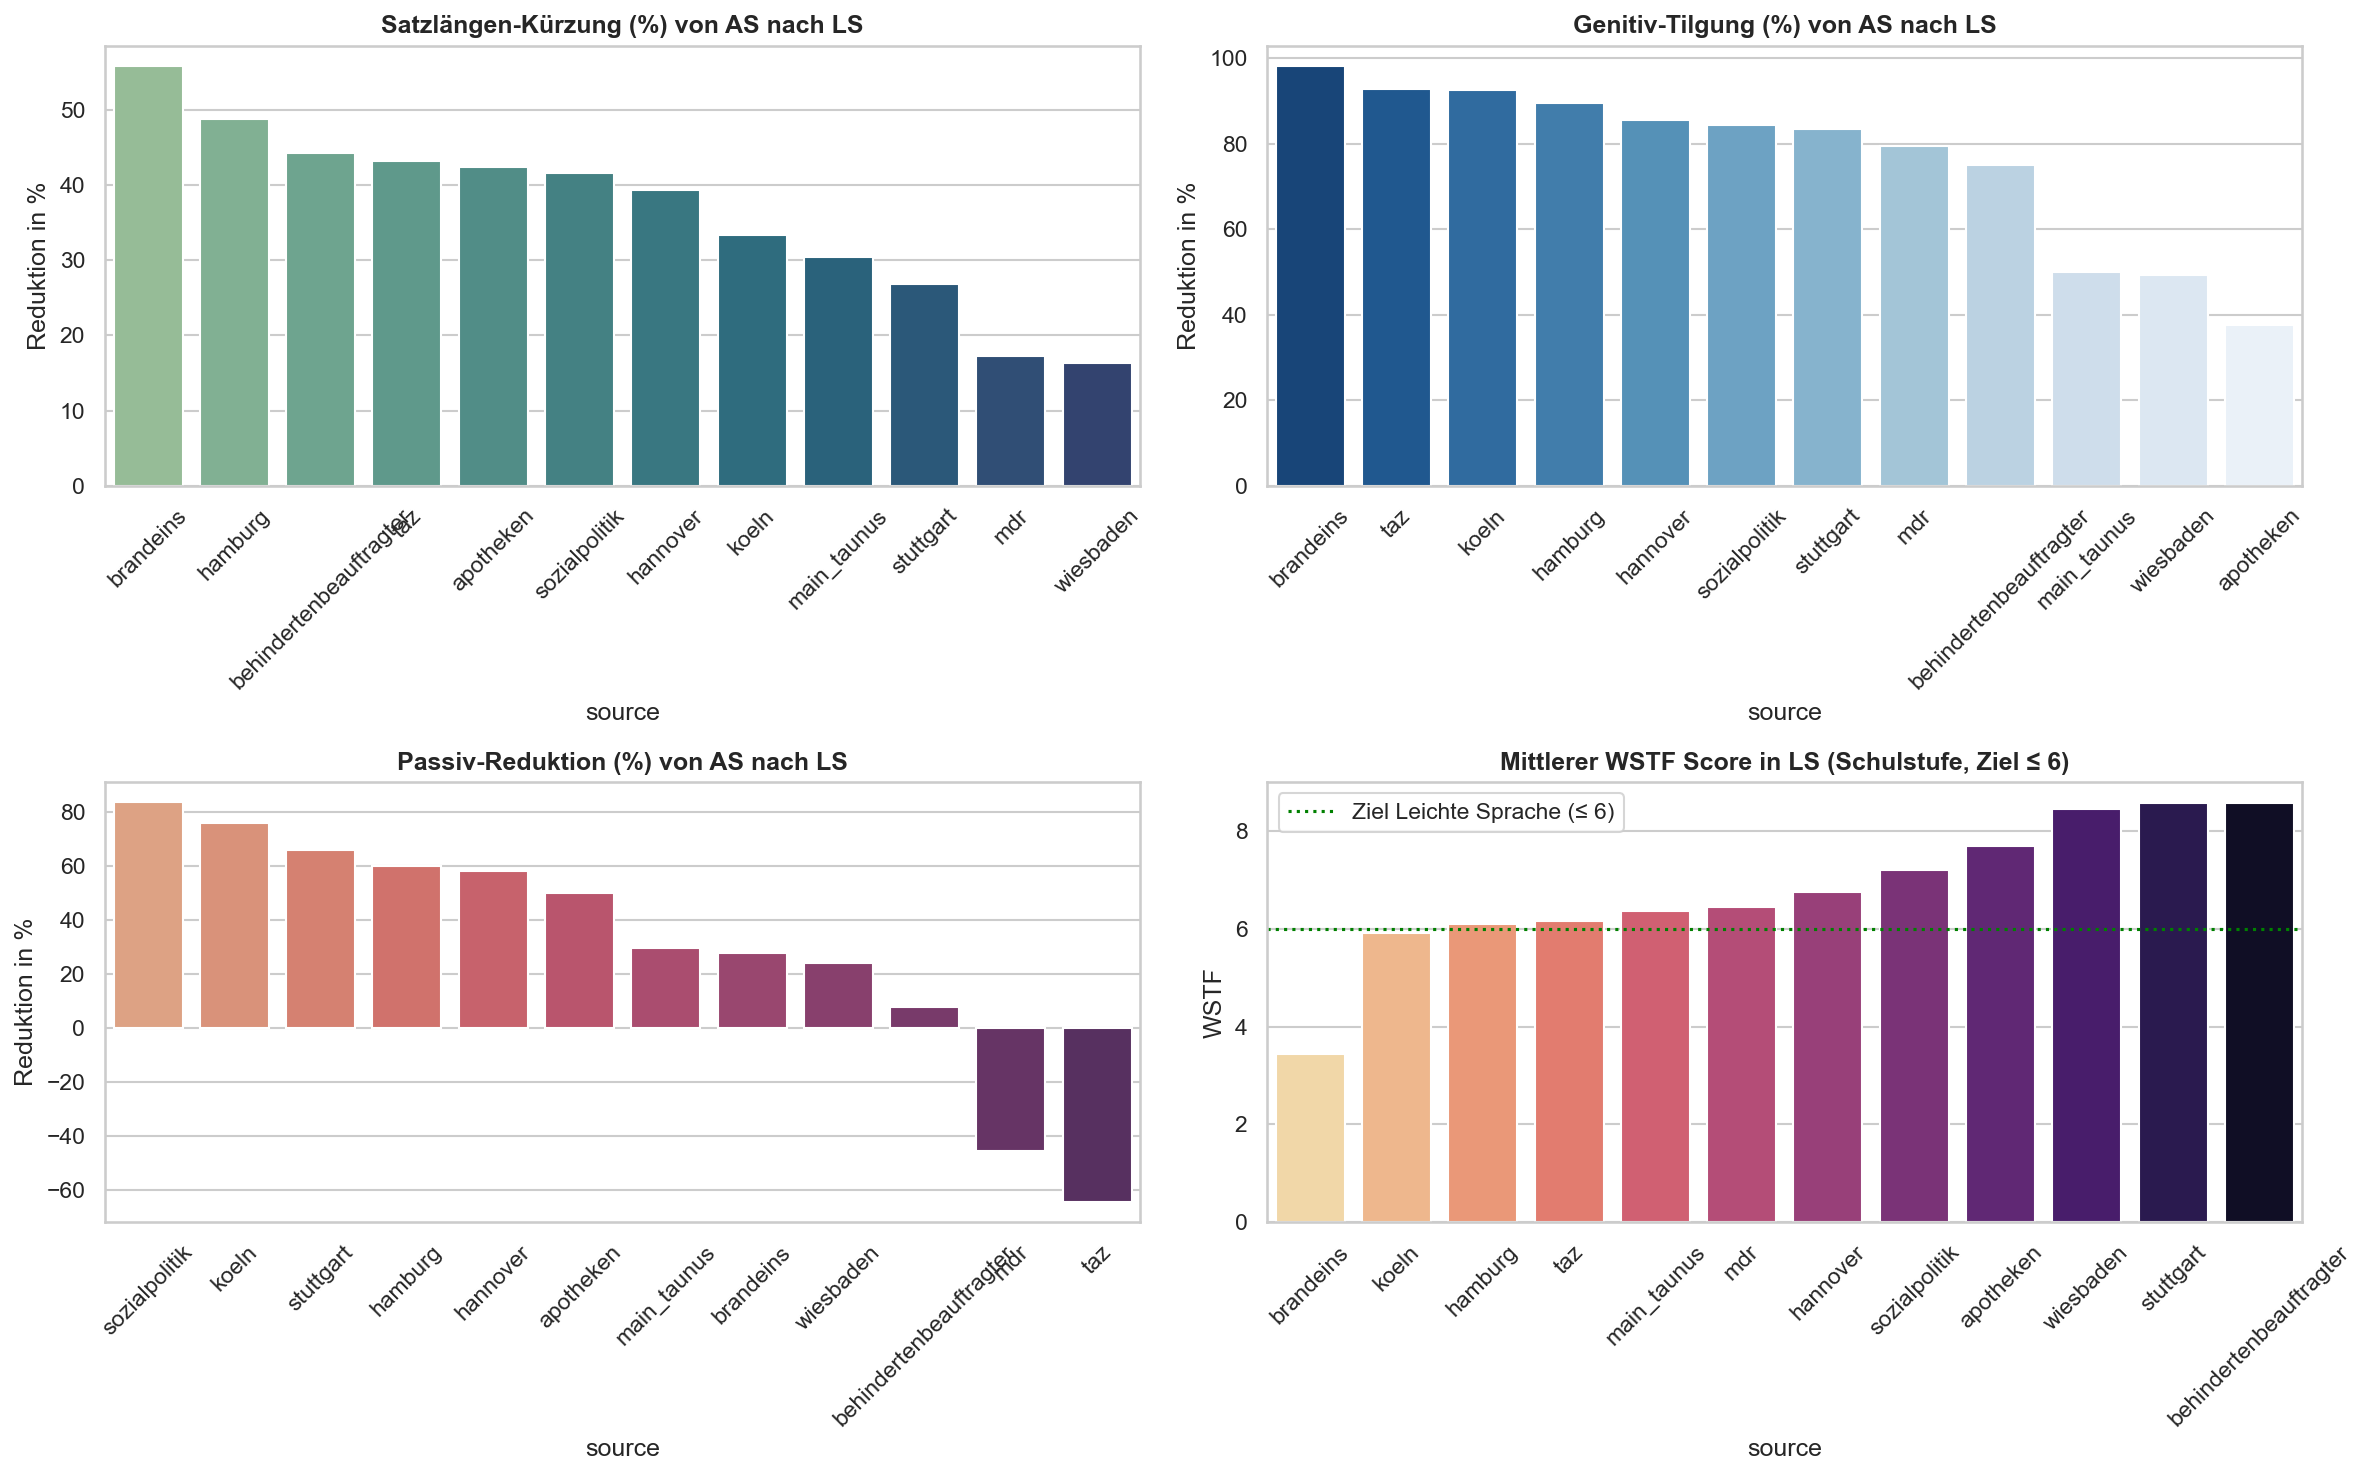

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
df_plot = df_corpus.groupby("source")[["red_red_sent_len_pct", "red_red_genitive_pct", "red_red_passive_pct", "ls_wstf_score"]].mean().reset_index()

# Satzlängen-Kürzung
sns.barplot(data=df_plot.sort_values("red_red_sent_len_pct", ascending=False), x="source", y="red_red_sent_len_pct", ax=axes[0, 0], hue="source", legend=False, palette="crest")
axes[0, 0].set_title("Satzlängen-Kürzung (%) von AS nach LS", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Reduktion in %")
axes[0, 0].tick_params(axis="x", rotation=45)

# Genitiv-Tilgung
sns.barplot(data=df_plot.sort_values("red_red_genitive_pct", ascending=False), x="source", y="red_red_genitive_pct", ax=axes[0, 1], hue="source", legend=False, palette="Blues_r")
axes[0, 1].set_title("Genitiv-Tilgung (%) von AS nach LS", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Reduktion in %")
axes[0, 1].tick_params(axis="x", rotation=45)

# Passiv-Reduktion
sns.barplot(data=df_plot.sort_values("red_red_passive_pct", ascending=False), x="source", y="red_red_passive_pct", ax=axes[1, 0], hue="source", legend=False, palette="flare")
axes[1, 0].set_title("Passiv-Reduktion (%) von AS nach LS", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Reduktion in %")
axes[1, 0].tick_params(axis="x", rotation=45)

# Wiener Sachtextformel in LS
sns.barplot(data=df_plot.sort_values("ls_wstf_score", ascending=True), x="source", y="ls_wstf_score", ax=axes[1, 1], hue="source", legend=False, palette="magma_r")
axes[1, 1].set_title("Mittlerer WSTF Score in LS (Schulstufe, Ziel ≤ 6)", fontsize=12, fontweight="bold")
axes[1, 1].axhline(6.0, color="green", linestyle=":", label="Ziel Leichte Sprache (≤ 6)")
axes[1, 1].set_ylabel("WSTF")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 3. Modell-Evaluation: Umfassendes Regel-Dashboard über alle Dimensionen


In [5]:
models_file = os.path.join(REPO_ROOT, "data/analysis/rule_adherence_models_comparison.csv")
if not os.path.exists(models_file):
    models_file = os.path.join(REPO_ROOT, "data/analysis/rule_adherence_ladder_sft.csv")
if not os.path.exists(models_file):
    models_file = os.path.join(REPO_ROOT, "data/analysis/rule_adherence_models_comparison.csv")
if not os.path.exists(models_file):
    models_file = os.path.join(REPO_ROOT, "data/analysis/rule_adherence_ladder_sft.csv")

df_models = pd.read_csv(models_file)
print(f"Regel-Adhärenz für Pipeline-Modelle geladen ({len(df_models)} Generierungen)")
print("Verfügbare Modelle:", list(df_models['model'].unique()) if 'model' in df_models.columns else "Keine model-Spalte")

metrics_map = {
    'avg_sent_len': '1. Satzlänge (Wörter)',
    'long_sent_ratio': '2. Lange Sätze (>12 W) %',
    'subord_ratio': '3. Nebensätze / Satz',
    'passive_ratio': '4. Passiv / Satz',
    'genitive_ratio': '5. Genitiv-Quote (pro Nomen)',
    'subjunctive_ratio': '6. Konjunktiv-Quote (pro Verb)',
    'nominal_ratio': '7. Nominalstil-Quote',
    'verb_to_noun_ratio': '8. Verb-zu-Nomen-Verhältnis',
    'polysyllable_ratio': '9. Polysilben-Quote (≥3 Silben)',
    'hyphen_compound_ratio': '10. Komposita-Trennung %',
    'abbr_ratio': '11. Abkürzungs-Quote',
    'digit_ratio': '12. Ziffern-Quote %',
    'wstf_score': '13. Wiener Sachtextformel',
    'flesch_score': '14. Flesch Reading Ease (DE)'
}

# -----------------------------------------------------------------------------
# TABELLE 1: Vollständige Matrix über ALLE Token-Längen (256, 512, 1024)
# -----------------------------------------------------------------------------
all_model_order = ['sft_len256', 'sft_len512', 'sft_len1024', 'dpo_len256', 'dpo_len512', 'dpo_len1024']
present_models = [m for m in all_model_order if 'model' in df_models.columns and m in df_models['model'].values]
if not present_models and 'model' in df_models.columns:
    present_models = list(df_models['model'].unique())

matrix_rows = []
for k, name in metrics_map.items():
    row = {'Regel-Metrik': name, 'AS Original': round(df_models[f'as_{k}'].mean(), 2)}
    for m in present_models:
        df_m = df_models[df_models['model'] == m]
        row[m] = round(df_m[f'gen_{k}'].mean(), 2)
    row['Lebenshilfe Gold'] = round(df_models[f'ref_{k}'].mean(), 2)
    matrix_rows.append(row)

print("\n--- TABELLE 1: Gesamt-Matrix über alle Token-Längen (256 / 512 / 1024) ---")
df_all_matrix = pd.DataFrame(matrix_rows)
display(df_all_matrix)

# -----------------------------------------------------------------------------
# TABELLE 2: Detail-Fokusvergleich für Best-Performer Standard (1024er Modelle)
# -----------------------------------------------------------------------------
sft_model_name = None
for candidate in ['sft_len1024', 'sft_len512', 'SFT Baseline', 'sft_len256']:
    if 'model' in df_models.columns and candidate in df_models['model'].values:
        sft_model_name = candidate
        break

dpo_model_name = None
for candidate in ['dpo_len1024', 'dpo_len512', 'DPO (0.5 Style / 0.5 Sem)', 'dpo_len256']:
    if 'model' in df_models.columns and candidate in df_models['model'].values:
        dpo_model_name = candidate
        break

sft_label = f"SFT ({sft_model_name})" if sft_model_name else "SFT Baseline"
dpo_label = f"DPO ({dpo_model_name})" if dpo_model_name else "DPO Alignment"

df_sft = df_models[df_models['model'] == sft_model_name] if (sft_model_name and 'model' in df_models.columns) else df_models
df_dpo = df_models[df_models['model'] == dpo_model_name] if (dpo_model_name and 'model' in df_models.columns) else None

rows = []
for k, name in metrics_map.items():
    as_val = df_sft[f"as_{k}"].mean()
    sft_val = df_sft[f"gen_{k}"].mean()
    ref_val = df_sft[f"ref_{k}"].mean()
    
    row_dict = {
        'Regel-Metrik': name,
        'AS Original': round(as_val, 3),
        sft_label: round(sft_val, 3),
    }
    if df_dpo is not None and not df_dpo.empty:
        dpo_val = df_dpo[f"gen_{k}"].mean()
        row_dict[dpo_label] = round(dpo_val, 3)
        
    row_dict['Lebenshilfe Gold'] = round(ref_val, 3)
    
    red_sft = ((as_val - sft_val) / as_val * 100) if as_val > 0 else 0
    row_dict['SFT Reduktion (%)'] = f"{red_sft:+.1f}%" if "Flesch" not in name and "Ziffer" not in name and "Verb-zu-Nomen" not in name and "Trennung" not in name else f"{(sft_val - as_val):+.2f} Pkt"
    rows.append(row_dict)

print(f"\n--- TABELLE 2: Detail-Vergleich für Standard-Best-Performer ({sft_model_name} / {dpo_model_name}) ---")
df_full_metrics = pd.DataFrame(rows)
display(df_full_metrics)


Regel-Adhärenz für Pipeline-Modelle geladen (222 Generierungen)
Verfügbare Modelle: ['sft_len256', 'sft_len512', 'sft_len1024', 'dpo_len256', 'dpo_len512', 'dpo_len1024']

--- TABELLE 1: Gesamt-Matrix über alle Token-Längen (256 / 512 / 1024) ---


,Regel-Metrik,AS Original,sft_len256,sft_len512,sft_len1024,dpo_len256,dpo_len512,dpo_len1024,Lebenshilfe Gold
0,1. Satzlänge (Wörter),12.50,9.51,9.75,7.61,8.04,8.55,6.97,6.79
1,2. Lange Sätze (>12 W) %,0.42,0.23,0.24,0.09,0.13,0.17,0.05,0.03
2,3. Nebensätze / Satz,0.11,0.08,0.09,0.04,0.07,0.09,0.06,0.02
3,4. Passiv / Satz,0.09,0.05,0.03,0.02,0.03,0.03,0.01,0.02
4,5. Genitiv-Quote (pro Nomen),0.09,0.05,0.05,0.02,0.03,0.03,0.01,0.01
5,6. Konjunktiv-Quote (pro Verb),0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00
6,7. Nominalstil-Quote,0.05,0.04,0.04,0.03,0.04,0.03,0.03,0.03
7,8. Verb-zu-Nomen-Verhältnis,0.41,0.54,0.50,0.65,0.64,0.60,0.76,0.57
8,9. Polysilben-Quote (≥3 Silben),0.33,0.27,0.27,0.21,0.23,0.24,0.18,0.23
9,10. Komposita-Trennung %,0.03,0.13,0.11,0.19,0.14,0.12,0.16,0.12



--- TABELLE 2: Detail-Vergleich für Standard-Best-Performer (sft_len1024 / dpo_len1024) ---


,Regel-Metrik,AS Original,SFT (sft_len1024),DPO (dpo_len1024),Lebenshilfe Gold,SFT Reduktion (%)
0,1. Satzlänge (Wörter),12.497,7.614,6.968,6.792,+39.1%
1,2. Lange Sätze (>12 W) %,0.424,0.093,0.048,0.033,+78.1%
2,3. Nebensätze / Satz,0.108,0.044,0.056,0.018,+58.9%
3,4. Passiv / Satz,0.093,0.023,0.005,0.020,+75.7%
4,5. Genitiv-Quote (pro Nomen),0.092,0.016,0.005,0.010,+82.7%
5,6. Konjunktiv-Quote (pro Verb),0.005,0.002,0.001,0.002,+62.2%
6,7. Nominalstil-Quote,0.050,0.034,0.026,0.034,+32.1%
7,8. Verb-zu-Nomen-Verhältnis,0.406,0.652,0.763,0.567,+0.25 Pkt
8,9. Polysilben-Quote (≥3 Silben),0.330,0.214,0.179,0.234,+35.1%
9,10. Komposita-Trennung %,0.029,0.188,0.163,0.117,+0.16 Pkt


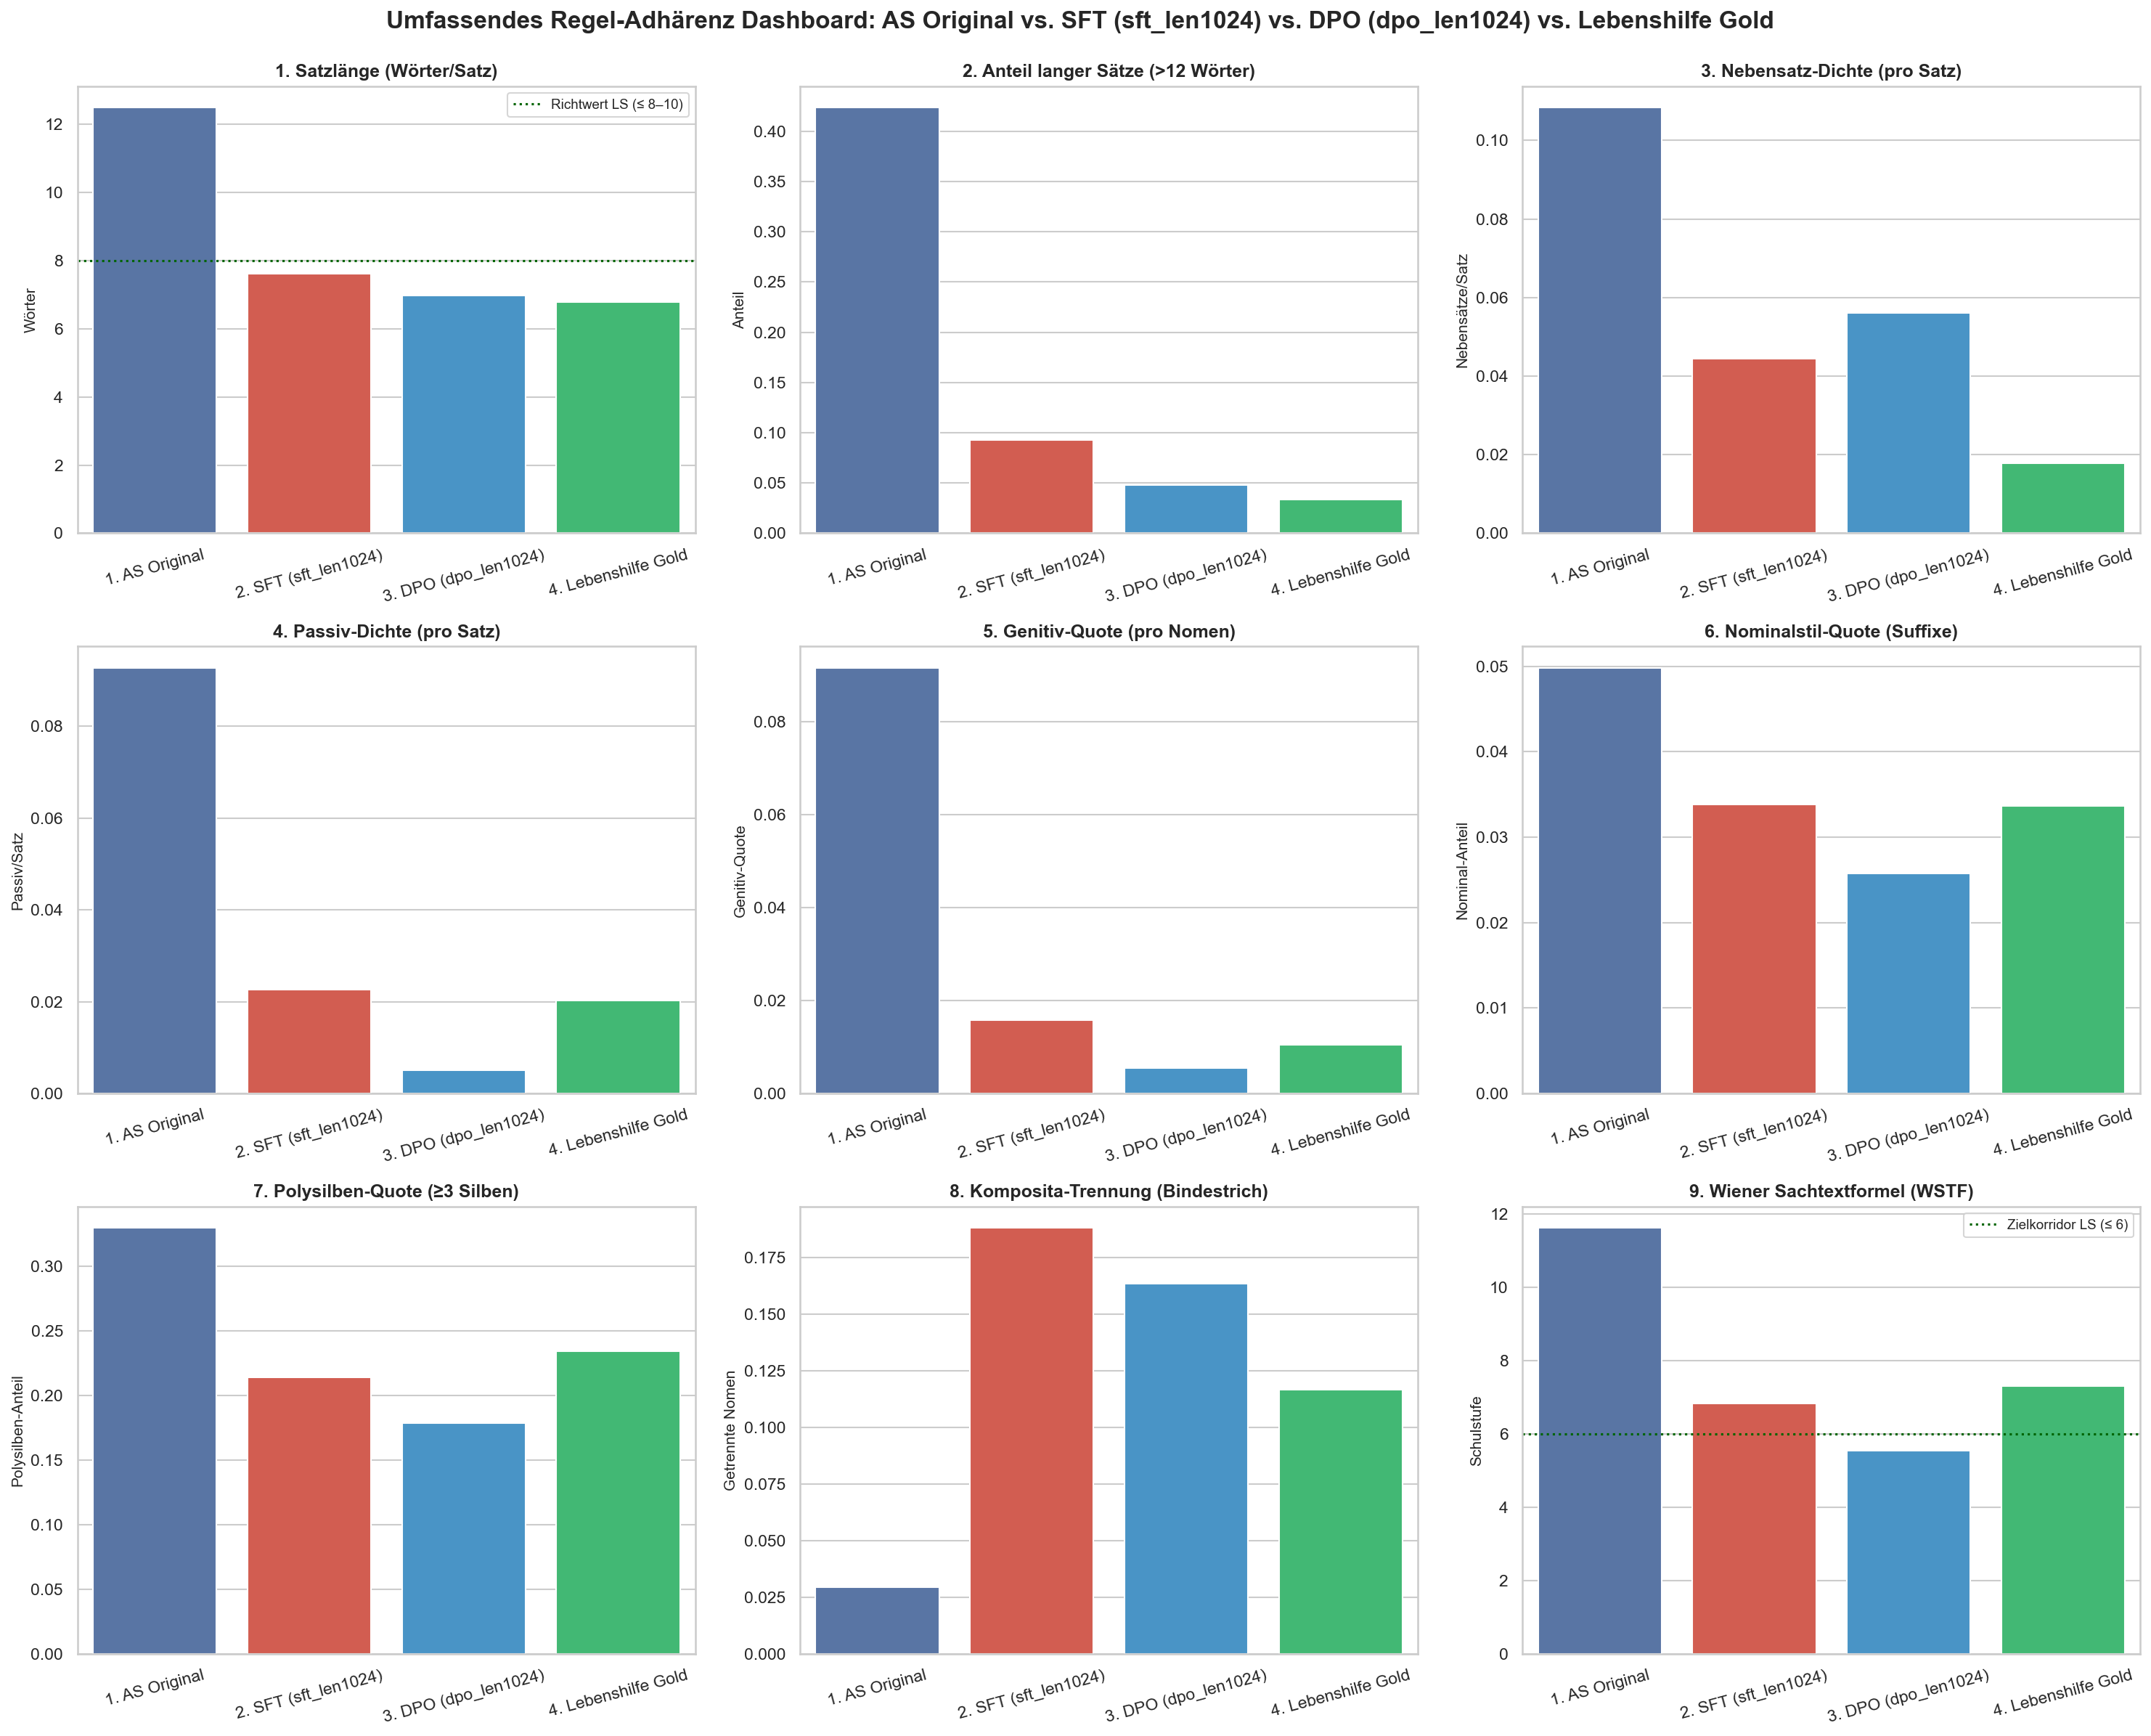

In [6]:
metrics_to_plot = [
    ('avg_sent_len', '1. Satzlänge (Wörter/Satz)', 'Wörter', 8.0, 'Richtwert LS (≤ 8–10)'),
    ('long_sent_ratio', '2. Anteil langer Sätze (>12 Wörter)', 'Anteil', None, None),
    ('subord_ratio', '3. Nebensatz-Dichte (pro Satz)', 'Nebensätze/Satz', None, None),
    ('passive_ratio', '4. Passiv-Dichte (pro Satz)', 'Passiv/Satz', None, None),
    ('genitive_ratio', '5. Genitiv-Quote (pro Nomen)', 'Genitiv-Quote', None, None),
    ('nominal_ratio', '6. Nominalstil-Quote (Suffixe)', 'Nominal-Anteil', None, None),
    ('polysyllable_ratio', '7. Polysilben-Quote (≥3 Silben)', 'Polysilben-Anteil', None, None),
    ('hyphen_compound_ratio', '8. Komposita-Trennung (Bindestrich)', 'Getrennte Nomen', None, None),
    ('wstf_score', '9. Wiener Sachtextformel (WSTF)', 'Schulstufe', 6.0, 'Zielkorridor LS (≤ 6)')
]

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

has_dpo = df_dpo is not None and not df_dpo.empty

for idx, (key, title, ylabel, threshold, thresh_label) in enumerate(metrics_to_plot):
    as_val = df_sft[f"as_{key}"].mean()
    sft_val = df_sft[f"gen_{key}"].mean()
    ref_val = df_sft[f"ref_{key}"].mean()

    data_rows = [
        {'Stufe': '1. AS Original', 'Wert': as_val},
        {'Stufe': f"2. {sft_label}", 'Wert': sft_val}
    ]
    if has_dpo:
        dpo_val = df_dpo[f"gen_{key}"].mean()
        data_rows.append({'Stufe': f"3. {dpo_label}", 'Wert': dpo_val})
        
    data_rows.append({'Stufe': '4. Lebenshilfe Gold' if has_dpo else '3. Lebenshilfe Gold', 'Wert': ref_val})
    
    df_p = pd.DataFrame(data_rows)

    palette = ['#4c72b0', '#e74c3c', '#3498db', '#2ecc71'] if has_dpo else ['#4c72b0', '#c44e52', '#55a868']

    ax = axes[idx]
    sns.barplot(data=df_p, x='Stufe', y='Wert', ax=ax, hue='Stufe', legend=False, palette=palette)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(axis='x', rotation=15)

    if threshold is not None:
        ax.axhline(threshold, color='darkgreen', linestyle=':', label=thresh_label)
        ax.legend(fontsize=9)

plt.suptitle(f"Umfassendes Regel-Adhärenz Dashboard: AS Original vs. {sft_label} vs. {dpo_label} vs. Lebenshilfe Gold", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## 4. Statistische Signifikanzen & Regel-Ranking


In [7]:
from scripts.evaluation.measure_rule_adherence import LeichteSpracheRuleAuditor

auditor = LeichteSpracheRuleAuditor()

def live_audit(as_text: str, ls_text: str):
    as_doc = auditor.nlp(as_text)
    ls_doc = auditor.nlp(ls_text)
    
    as_m = auditor.analyze_doc(as_doc)
    ls_m = auditor.analyze_doc(ls_doc)
    red_m = auditor.calculate_reduction_delta(as_m, ls_m)
    
    print("=================== LIVE REGEL-AUDIT ===================")
    print(f"[AS Original]: {as_text[:120]}...")
    print(f"[LS Zieltext]: {ls_text[:120]}...")
    print("--------------------------------------------------------")
    print(f"Satzlänge:        {as_m['avg_sent_len']:.1f} Wörter -> {ls_m['avg_sent_len']:.1f} Wörter ({red_m['red_sent_len_pct']:+.1f}% Reduktion)")
    print(f"Passiv/Satz:      {as_m['passive_ratio']:.2f} -> {ls_m['passive_ratio']:.2f} ({red_m['red_passive_pct']:+.1f}% Reduktion)")
    print(f"Genitiv-Quote:    {as_m['genitive_ratio']:.2f} -> {ls_m['genitive_ratio']:.2f} ({red_m['red_genitive_pct']:+.1f}% Reduktion)")
    print(f"Nebensatz-Dichte: {as_m['subord_ratio']:.2f} -> {ls_m['subord_ratio']:.2f} ({red_m['red_subord_pct']:+.1f}% Reduktion)")
    print(f"Nominalstil:      {as_m['nominal_ratio']:.2f} -> {ls_m['nominal_ratio']:.2f} ({red_m['red_nominal_pct']:+.1f}% Reduktion)")
    print(f"WSTF (Lesbarkeit): {as_m['wstf_score']:.1f} -> {ls_m['wstf_score']:.1f}")
    print("========================================================")

# Test-Beispiel:
as_sample = "Die Genehmigung des Antrags wird durch die zuständige Behörde nach sorgfältiger Prüfung der Unterlagen erteilt."
ls_sample = "Das Amt prüft die Papiere. Danach erlaubt das Amt den Antrag."
live_audit(as_sample, ls_sample)


Loading SpaCy model: de_core_news_lg...
=================== LIVE REGEL-AUDIT ===================
[AS Original]: Die Genehmigung des Antrags wird durch die zuständige Behörde nach sorgfältiger Prüfung der Unterlagen erteilt....
[LS Zieltext]: Das Amt prüft die Papiere. Danach erlaubt das Amt den Antrag....
--------------------------------------------------------
Satzlänge:        15.0 Wörter -> 5.5 Wörter (+63.3% Reduktion)
Passiv/Satz:      1.00 -> 0.00 (+100.0% Reduktion)
Genitiv-Quote:    0.40 -> 0.00 (+100.0% Reduktion)
Nebensatz-Dichte: 0.00 -> 0.00 (+0.0% Reduktion)
Nominalstil:      0.13 -> 0.00 (+100.0% Reduktion)
WSTF (Lesbarkeit): 13.5 -> 2.1
